In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [11]:
import pandas as pd
import pulp


def run_co_optimization_with_afrr(
    df: pd.DataFrame,
    capacity_mwh: float = 10.0,
    max_power_mw: float = 5.0,
    grid_fee_penalty_rate: float = 150.0,
):
  """Runs MILP co-optimization for EPEX Day-Ahead, aFRR capacity,

  and Industrial Peak Shaving (§ 19 StromNEV).
  """
  model = pulp.LpProblem("BESS_DA_aFRR_CoOptimization", pulp.LpMaximize)

  time_steps = len(df)

  # Decision Variables
  # P_ch: Charging power, P_dis: Discharging power
  P_ch = {
      t: pulp.LpVariable(f"P_ch_{t}", lowBound=0, upBound=max_power_mw)
      for t in range(time_steps)
  }
  P_dis = {
      t: pulp.LpVariable(f"P_dis_{t}", lowBound=0, upBound=max_power_mw)
      for t in range(time_steps)
  }

  # aFRR Capacity Reserved (MW) - Symmetrical or positive/negative
  P_afrr = {
      t: pulp.LpVariable(f"P_afrr_{t}", lowBound=0, upBound=max_power_mw)
      for t in range(time_steps)
  }

  # Binary variable to prevent simultaneous charging and discharging
  u_dis = {
      t: pulp.LpVariable(f"u_dis_{t}", cat="Binary") for t in range(time_steps)
  }

  # State of Charge (SoC)
  SoC = {
      t: pulp.LpVariable(f"SoC_{t}", lowBound=0, upBound=capacity_mwh)
      for t in range(time_steps + 1)
  }

  # Grid peak power variable for penalty calculation
  P_peak_grid = pulp.LpVariable(
      "P_peak_grid", lowBound=0, upBound=max_power_mw * 3
  )

  # Initial SoC condition
  model += SoC[0] == capacity_mwh * 0.5

  # Objective Function: Maximize (DA Arbitrage + aFRR Capacity Revenue - Grid Peak Penalty)
  revenue_da = pulp.lpSum(
      (P_dis[t] - P_ch[t]) * df.loc[t, "DA_Price_EUR_MWh"] for t in range(time_steps)
  )
  revenue_afrr = pulp.lpSum(
      P_afrr[t] * df.loc[t, "aFRR_Cap_Price_EUR_MW"] for t in range(time_steps)
  )
  penalty_grid = P_peak_grid * grid_fee_penalty_rate

  model += revenue_da + revenue_afrr - penalty_grid

  # Constraints for each time step
  eff = 0.92  # Round-trip efficiency factor

  for t in range(time_steps):
    # 1. Mutual exclusivity of charging and discharging
    model += P_dis[t] <= max_power_mw * u_dis[t]
    model += P_ch[t] <= max_power_mw * (1 - u_dis[t])

    # 2. Power capacity headroom including aFRR reservation
    # The battery must have enough power headroom to deliver aFRR while discharging/charging
    model += P_dis[t] + P_afrr[t] <= max_power_mw
    model += P_ch[t] + P_afrr[t] <= max_power_mw

    # 3. State of Charge dynamics
    if t < time_steps - 1:
      model += SoC[t + 1] == SoC[t] + (
          P_ch[t] * eff - P_dis[t] / eff
      ) * 1.0  # assuming 1-hour steps

    # 4. Grid peak tracking for § 19 StromNEV
    industrial_load = df.loc[t, "Industrial_Load_MW"]
    net_grid_load = industrial_load + P_ch[t] - P_dis[t]
    model += P_peak_grid >= net_grid_load

  # Solve the model using CBC solver
  model.solve(pulp.PULP_CBC_CMD(msg=0))

  # Extract results into a DataFrame
  results_df = df.copy()
  results_df["Optimized_Discharge_MW"] = [
      pulp.value(P_dis[t]) for t in range(time_steps)
  ]
  results_df["Optimized_Charge_MW"] = [
      pulp.value(P_ch[t]) for t in range(time_steps)
  ]
  results_df["aFRR_Reserved_MW"] = [
      pulp.value(P_afrr[t]) for t in range(time_steps)
  ]
  results_df["SoC_MWh"] = [pulp.value(SoC[t]) for t in range(time_steps)]
  results_df["Net_Grid_Load_MW"] = (
      results_df["Industrial_Load_MW"]
      + results_df["Optimized_Charge_MW"]
      - results_df["Optimized_Discharge_MW"]
  )

  return results_df

In [12]:
import pandas as pd
import numpy as np

# 1. Generate or load sample market data with aFRR prices
def generate_sample_market_data(num_hours=24):
    np.random.seed(42)
    timestamps = pd.date_range(start="2026-06-01 00:00:00", periods=num_hours, freq="h")

    # Simulating Day-Ahead prices, aFRR capacity prices, and industrial load
    da_prices = 80 + 40 * np.sin(np.linspace(0, 2 * np.pi, num_hours)) + np.random.normal(0, 10, num_hours)
    afrr_prices = 25 + 10 * np.abs(np.cos(np.linspace(0, 2 * np.pi, num_hours))) + np.random.normal(0, 3, num_hours)
    industrial_load = 5 + 2 * np.sin(np.linspace(0, 2 * np.pi, num_hours) - 1) + np.random.normal(0, 0.5, num_hours)

    df = pd.DataFrame({
        "Timestamp": timestamps,
        "DA_Price_EUR_MWh": da_prices,
        "aFRR_Cap_Price_EUR_MW": afrr_prices,
        "Industrial_Load_MW": industrial_load
    })
    return df

# Initialize market dataframe
market_df = generate_sample_market_data()

# 2. Run the co-optimization model with aFRR and peak shaving
results = run_co_optimization_with_afrr(
    market_df,
    capacity_mwh=10.0,
    max_power_mw=5.0,
    grid_fee_penalty_rate=150.0
)

# 3. Calculate total daily revenues from Day-Ahead and aFRR
da_revenue = (results["Optimized_Discharge_MW"] - results["Optimized_Charge_MW"]) * results["DA_Price_EUR_MWh"]
afrr_revenue = results["aFRR_Reserved_MW"] * results["aFRR_Cap_Price_EUR_MW"]

total_da_rev = da_revenue.sum()
total_afrr_rev = afrr_revenue.sum()
combined_revenue = total_da_rev + total_afrr_rev

# Print financial summary
print(f"💰 Total EPEX Day-Ahead Revenue: €{total_da_rev:,.2f}")
print(f"🛡️ Total aFRR Capacity Revenue: €{total_afrr_rev:,.2f}")
print(f"🚀 Combined Daily Revenue: €{combined_revenue:,.2f}")

# Display first 10 rows of the optimization results table
display(results[[
    "Timestamp",
    "DA_Price_EUR_MWh",
    "aFRR_Cap_Price_EUR_MW",
    "Optimized_Discharge_MW",
    "aFRR_Reserved_MW",
    "SoC_MWh"
]].head(10))

💰 Total EPEX Day-Ahead Revenue: €911.36
🛡️ Total aFRR Capacity Revenue: €3,377.80
🚀 Combined Daily Revenue: €4,289.16


,Timestamp,DA_Price_EUR_MWh,aFRR_Cap_Price_EUR_MW,Optimized_Discharge_MW,aFRR_Reserved_MW,SoC_MWh
0,2026-06-01 00:00:00,84.967142,33.366852,0.000000,5.000000,5.000000
1,2026-06-01 01:00:00,89.409228,34.961941,0.000000,5.000000,5.000000
2,2026-06-01 02:00:00,107.260243,30.091213,0.000000,5.000000,5.000000
3,2026-06-01 03:00:00,124.463737,32.952625,0.000000,5.000000,5.000000
4,2026-06-01 04:00:00,113.173875,27.798734,0.000000,5.000000,5.000000
5,2026-06-01 05:00:00,116.821994,26.159479,0.000000,5.000000,5.000000
6,2026-06-01 06:00:00,135.698879,23.877304,3.609107,1.390893,5.000000
7,2026-06-01 07:00:00,125.364784,33.905631,0.214607,4.785393,1.077058
8,2026-06-01 08:00:00,107.984052,30.726312,0.000000,5.000000,0.843789
9,2026-06-01 09:00:00,110.669118,29.583980,0.000000,5.000000,0.843789


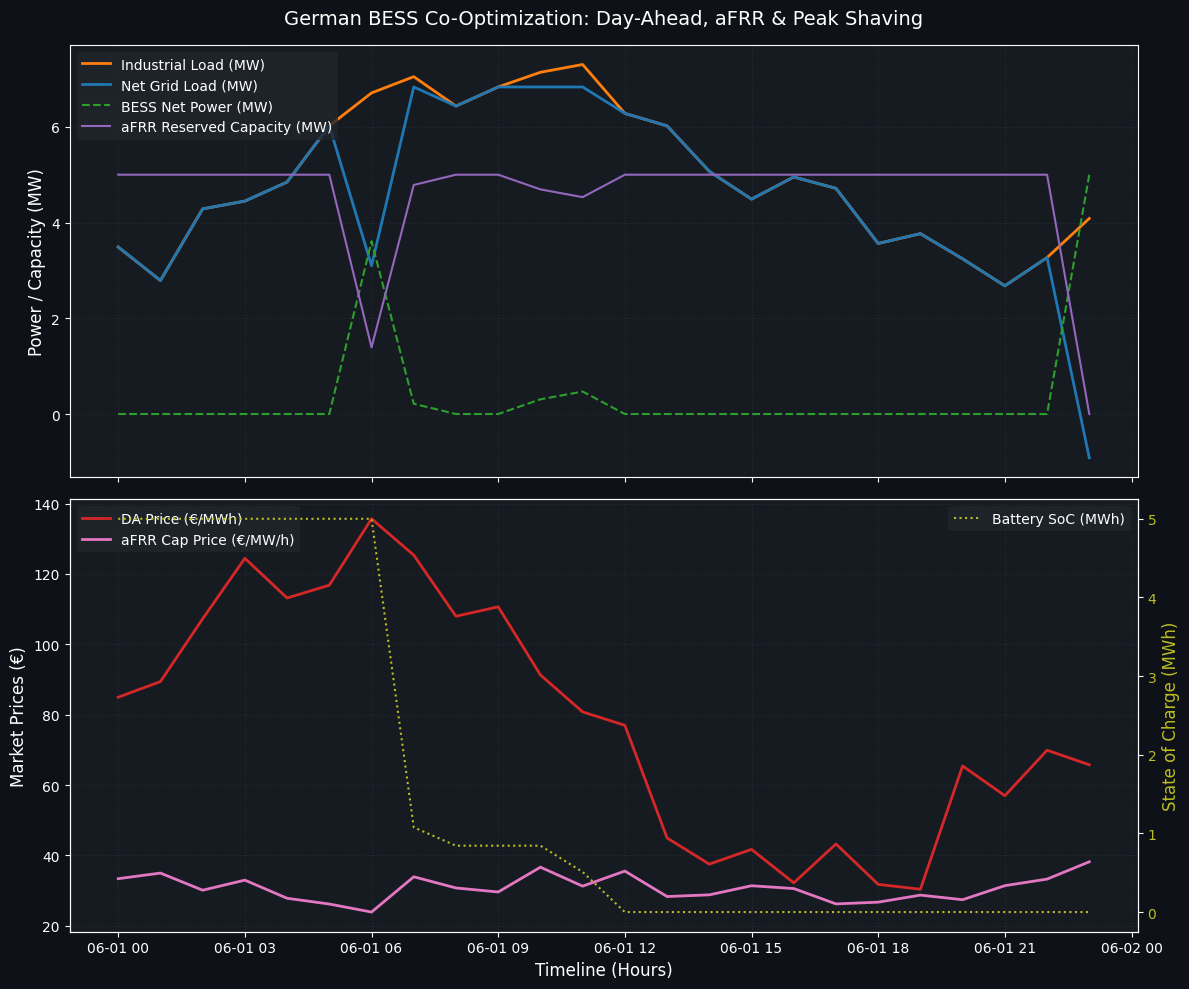

⚙️ Generating chronological dispatch animation GIF...


/tmp/ipykernel_771/2208591300.py:135: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


✅ Success! Charts saved as 'german_bess_co_optimization_dark.png' and GIF animation saved as 'bess_dispatch_animation.gif'.


In [13]:
import matplotlib.pyplot as plt
import imageio
import os
import numpy as np
import pandas as pd

# 1. Ensure dark background style for matplotlib
plt.style.use("dark_background")

# Create figure with dual y-axes for multi-layer metrics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Set background colors to match dark theme UI
fig.patch.set_facecolor("#0e1117")
ax1.set_facecolor("#161b22")
ax2.set_facecolor("#161b22")

# --- Plot 1: Power Dispatch, Peak Shaving & aFRR Reservation ---
ax1.plot(
    results["Timestamp"],
    results["Industrial_Load_MW"],
    label="Industrial Load (MW)",
    color="#ff7f0e",
    linewidth=2,
)
ax1.plot(
    results["Timestamp"],
    results["Net_Grid_Load_MW"],
    label="Net Grid Load (MW)",
    color="#1f77b4",
    linewidth=2,
)
ax1.plot(
    results["Timestamp"],
    results["Optimized_Discharge_MW"] - results["Optimized_Charge_MW"],
    label="BESS Net Power (MW)",
    color="#2ca02c",
    linewidth=1.5,
    linestyle="--",
)
ax1.plot(
    results["Timestamp"],
    results["aFRR_Reserved_MW"],
    label="aFRR Reserved Capacity (MW)",
    color="#9467bd",
    linewidth=1.5,
)

ax1.set_ylabel("Power / Capacity (MW)", color="white", fontsize=12)
ax1.set_title(
    "German BESS Co-Optimization: Day-Ahead, aFRR & Peak Shaving",
    color="white",
    fontsize=14,
    pad=15,
)
ax1.legend(loc="upper left", facecolor="#21262d", edgecolor="none", fontsize=10)
ax1.grid(True, color="#30363d", linestyle=":", alpha=0.6)

# --- Plot 2: Market Prices & State of Charge (SoC) ---
ax2.plot(
    results["Timestamp"],
    results["DA_Price_EUR_MWh"],
    label="DA Price (€/MWh)",
    color="#d62728",
    linewidth=2,
)
ax2.plot(
    results["Timestamp"],
    results["aFRR_Cap_Price_EUR_MW"],
    label="aFRR Cap Price (€/MW/h)",
    color="#e377c2",
    linewidth=2,
)

ax2_soc = ax2.twinx()
ax2_soc.plot(
    results["Timestamp"],
    results["SoC_MWh"],
    label="Battery SoC (MWh)",
    color="#bcbd22",
    linewidth=1.5,
    linestyle=":",
)
ax2_soc.set_ylabel("State of Charge (MWh)", color="#bcbd22", fontsize=12)
ax2_soc.tick_params(axis="y", labelcolor="#bcbd22")

ax2.set_ylabel("Market Prices (€)", color="white", fontsize=12)
ax2.set_xlabel("Timeline (Hours)", color="white", fontsize=12)
ax2.legend(loc="upper left", facecolor="#21262d", edgecolor="none", fontsize=10)
ax2_soc.legend(
    loc="upper right", facecolor="#21262d", edgecolor="none", fontsize=10
)
ax2.grid(True, color="#30363d", linestyle=":", alpha=0.6)

plt.tight_layout()

# Save static high-res dark theme chart
chart_filename = "german_bess_co_optimization_dark.png"
plt.savefig(chart_filename, dpi=300, facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

# --- 2. Generate Chronological Dispatch GIF Animation ---
print("⚙️ Generating chronological dispatch animation GIF...")
frame_filenames = []
temp_dir = "temp_frames"
os.makedirs(temp_dir, exist_ok=True)

for i in range(1, len(results) + 1):
    fig_anim, ax_anim = plt.subplots(figsize=(10, 5))
    fig_anim.patch.set_facecolor("#0e1117")
    ax_anim.set_facecolor("#161b22")

    sub_df = results.iloc[:i]
    ax_anim.plot(results["Timestamp"], results["Industrial_Load_MW"], color="#ff7f0e", alpha=0.3, label="Full Load")
    ax_anim.plot(sub_df["Timestamp"], sub_df["Industrial_Load_MW"], color="#ff7f0e", linewidth=2.5, label="Industrial Load")
    ax_anim.plot(sub_df["Timestamp"], sub_df["Net_Grid_Load_MW"], color="#1f77b4", linewidth=2.5, label="Net Grid Load")

    ax_anim.set_xlim(results["Timestamp"].iloc[0], results["Timestamp"].iloc[-1])
    ax_anim.set_ylim(-2, 10)
    ax_anim.set_title(f"BESS 24-Hour Dispatch Progress - Hour {i}", color="white", fontsize=12)
    ax_anim.set_ylabel("Power (MW)", color="white")
    ax_anim.grid(True, color="#30363d", linestyle=":", alpha=0.6)
    ax_anim.legend(loc="upper left", facecolor="#21262d", edgecolor="none")

    frame_path = os.path.join(temp_dir, f"frame_{i:02d}.png")
    plt.tight_layout()
    plt.savefig(frame_path, dpi=100, facecolor=fig_anim.get_facecolor(), edgecolor='none')
    plt.close(fig_anim)
    frame_filenames.append(frame_path)

# Compile frames into a GIF
gif_filename = "bess_dispatch_animation.gif"
with imageio.get_writer(gif_filename, mode='I', duration=0.4) as writer:
    for filename in frame_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# Clean up temporary frame files
for filename in frame_filenames:
    os.remove(filename)
os.rmdir(temp_dir)

print(f"✅ Success! Charts saved as '{chart_filename}' and GIF animation saved as '{gif_filename}'.")

In [14]:
from google.colab import files
import pandas as pd

# Define the CSV filename
csv_filename = "german_bess_co_optimization_results.csv"

# Save the results DataFrame to CSV
results.to_csv(csv_filename, index=False)

# Trigger automatic download to your local machine
files.download(csv_filename)

print(f"✅ CSV file '{csv_filename}' has been successfully generated and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ CSV file 'german_bess_co_optimization_results.csv' has been successfully generated and downloaded!
